In [19]:
# Import Libraries
import tensorflow
import keras
from keras.layers import Dense, Input, Flatten
from keras  import Sequential
from keras.datasets import mnist
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
# Load Dataset
(X_train, y_train), (X_test, y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
# Shape of the data
X_train.shape

(60000, 28, 28)

In [5]:
# Show y_train
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [6]:
# Scale the dataset
X_train=X_train/255
X_test=X_test/255

In [8]:
# Create the neural Network model
model=Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(10,activation='softmax'))      # For multiclass use equal nodes of class number


In [9]:
# Model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Configure the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [18]:
# Train the model
history=model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0626 - val_loss: 0.1308
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0572 - val_loss: 0.1258
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0532 - val_loss: 0.1308
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0493 - val_loss: 0.1325
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0450 - val_loss: 0.1370
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0418 - val_loss: 0.1477
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0387 - val_loss: 0.1529
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0367 - val_loss: 0.1576
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0343 - val_loss: 0.1626
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0317 - val_loss: 0.1660


In [12]:
# Predic the model
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [13]:
# Finout the orginal value
y_pred=y_prob.argmax(axis=1)

In [17]:
# Findout the accuracy
accuracy_score(y_test, y_pred)*100

96.61

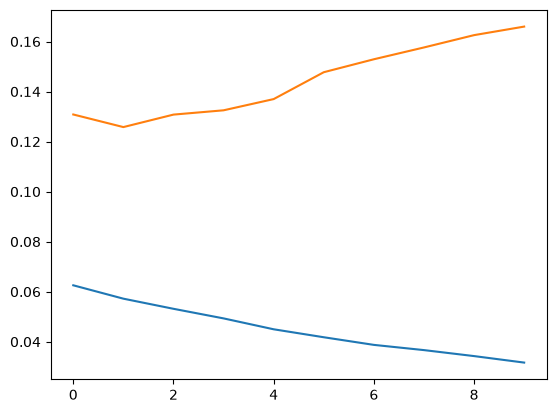

In [ ]:
# Show the loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])